In [1]:
from pathlib import Path
import json
import warnings
from typing import Dict, List, Optional, Sequence, Set, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from plot_template import (
    PALETTE,
    set_paper_style,
    add_legend,
    styled_axes,
    plot_series,
)

set_paper_style()

PHASE_STYLES = {
    "icnn_pretrain": {"color": "#E8DFFF", "alpha": 0.30},
    "adv_finetune": {"color": "#FFE7C2", "alpha": 0.30},
    "icnn": {"color": "#D6F4E1", "alpha": 0.28},
    "erm": {"color": "#F9D0D1", "alpha": 0.28},
}
DEFAULT_PHASE_STYLE = {"color": "#E2E0D5", "alpha": 0.2}
PHASE_LABELS = {
    "icnn_pretrain": "ICNN pre-train",
    "adv_finetune": "Adversarial finetune",
    "icnn": "Joint ICNN training",
    "erm": "ERM",
}



COLOR_CYCLE = ["mars", "signum", "lion", "sf-adamw"]


def coerce_path_list(paths: Sequence[Union[str, Path]]) -> List[Path]:
    """Expand user prefixes and convert inputs into Path objects."""
    coerced: List[Path] = []
    for item in paths:
        path = Path(item).expanduser() if not isinstance(item, Path) else item.expanduser()
        coerced.append(path)
    return coerced






def tex_escape(text: str) -> str:
    """Escape common characters for LaTeX text."""
    specials = {
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
    }
    pieces = []
    for ch in text:
        if ch == "\\":
            pieces.append(r"\textbackslash{}")
        else:
            pieces.append(specials.get(ch, ch))
    return ''.join(pieces)





def load_model_metrics(json_paths: Sequence[Path], model_label: str):
    """Collect epsilon and robust accuracy pairs for a model."""
    records = []
    for path in json_paths:
        with open(path, "r") as f:
            data = json.load(f)

        scores = data.get("scores", {})
        pgd_params = scores.get("pgd_params", {})
        cifar10_pgd = scores.get("cifar10_pgd", {})
        eps = pgd_params.get("eps")
        robust_acc = cifar10_pgd.get("acc")

        if eps is None or robust_acc is None:
            continue

        records.append((float(eps), float(robust_acc), path.name))

    if not records:
        raise ValueError(f"No PGD metrics found for {model_label} in {len(json_paths)} file(s).")
    records.sort(key=lambda item: item[0])
    eps_values = np.array([item[0] for item in records])
    robust_values = np.array([item[1] for item in records])
    source_files = [item[2] for item in records]
    return eps_values, robust_values, source_files


def harmonize_epsilons(eps_values: np.ndarray, denominator: int = 255) -> np.ndarray:
    """Snap epsilon values to multiples of 1/denominator to avoid duplicate ticks."""
    return np.round(eps_values * denominator) / denominator




def _resolve_relative_path(path: Path) -> str:
    try:
        return str(path.relative_to(Path.cwd()))
    except ValueError:
        return str(path)


def _merge_sources(series: pd.Series) -> str:
    unique = sorted({str(x) for x in series if pd.notna(x) and str(x).strip()})
    return ", ".join(unique)


def load_weight_delta_frames(csv_paths: Sequence[Path]):
    required = {"theta_weight_delta", "icnn_weight_delta", "epoch", "phase"}
    frames = []
    skipped: List[Path] = []
    for path in csv_paths:
        try:
            df = pd.read_csv(path)
        except Exception:
            skipped.append(path)
            continue
        if not required.issubset(df.columns):
            skipped.append(path)
            continue
        df = df.copy()
        if "run_id" not in df.columns or df["run_id"].isnull().all():
            inferred = path.parent.name or path.stem
            df["run_id"] = inferred
        df["source"] = _resolve_relative_path(path)
        frames.append(df)
    if not frames:
        raise ValueError(
            "No CSV logs contained the required weight delta columns. "
            "Re-run training after updating `pretrained_LAT_icnn.py`."
        )
    combined = pd.concat(frames, ignore_index=True)
    # Ensure integer epochs for sorting and plotting
    combined["epoch"] = combined["epoch"].astype(int)
    combined.sort_values(["run_id", "epoch"], inplace=True)

    agg_map: Dict[str, object] = {
        "phase": "first",
        "source": _merge_sources,
    }
    for col in combined.columns:
        if col in {"run_id", "epoch", "phase", "source"}:
            continue
        agg_map[col] = "first"

    combined = (
        combined.groupby(["run_id", "epoch"], as_index=False)
        .agg(agg_map)
        .sort_values(["run_id", "epoch"])
        .reset_index(drop=True)
    )
    return combined, skipped


def _style_axis(ax: plt.Axes) -> None:
    ax.set_facecolor(PALETTE["bg"])
    for spine in ax.spines.values():
        spine.set_linewidth(1.6)
        spine.set_color(PALETTE["spine"])
    ax.grid(axis="y", which="major", linestyle=(0, (4, 4)), linewidth=0.5,
            color=PALETTE["gridblue"], alpha=0.45)
    ax.grid(False, axis="x")


def _phase_spans(df: pd.DataFrame) -> List[Tuple[float, float, str]]:
    epochs = df["epoch"].to_numpy()
    phases = df["phase"].astype(str).to_numpy()
    if epochs.size == 0:
        return []
    spans: List[Tuple[float, float, str]] = []
    start_epoch = epochs[0]
    current_phase = phases[0]
    prev_epoch = epochs[0]
    for epoch, phase in zip(epochs[1:], phases[1:]):
        if phase != current_phase:
            spans.append((start_epoch - 0.5, prev_epoch + 0.5, current_phase))
            start_epoch = epoch
            current_phase = phase
        prev_epoch = epoch
    spans.append((start_epoch - 0.5, prev_epoch + 0.5, current_phase))
    return spans


def _apply_phase_bands(
    ax: plt.Axes,
    spans: Sequence[Tuple[float, float, str]],
    *,
    seen: Optional[Set[str]] = None,
):
    if seen is None:
        seen = set()
    handles = []
    for left, right, phase in spans:
        style = PHASE_STYLES.get(phase, DEFAULT_PHASE_STYLE)
        label = None
        if phase not in seen:
            label = PHASE_LABELS.get(phase, phase.replace("_", " ").title())
            seen.add(phase)
        patch = ax.axvspan(left, right, label=label if label else "_nolegend_",
                           zorder=0.05, **style)
        if label:
            handles.append(patch)
    return handles, seen


def _finite_array(values: np.ndarray) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float64)
    return arr[np.isfinite(arr)]


def _safe_stat(values: np.ndarray, fn) -> float:
    finite = _finite_array(values)
    if finite.size == 0:
        return float("nan")
    return float(fn(finite))


def plot_robust_accuracy(
    json_config: Dict[str, Sequence[Path]],
    *,
    save_path: Optional[Path] = None,
):
    """Plot robust accuracies from a manual JSON configuration mapping."""
    if not json_config:
        print("No evaluation JSON configuration provided; skipping robust accuracy plot.")
        return None, {}

    series_info = []
    source_map: Dict[str, List[str]] = {}
    for idx, (label, paths) in enumerate(json_config.items()):
        if not paths:
            continue
        try:
            eps_values, robust_values, _ = load_model_metrics(paths, label)
        except ValueError as err:
            warnings.warn(f"Skipping '{label}': {err}", RuntimeWarning)
            continue
        eps_values = harmonize_epsilons(eps_values)
        series_info.append((label, eps_values, robust_values))
        source_map[label] = [str(p) for p in paths]

    if not series_info:
        print("No evaluation data available for plotting.")
        return None, {}

    fig, ax = styled_axes(figsize=(6.5, 4.0))
    xticks = np.unique(np.concatenate([eps for _, eps, _ in series_info]))
    robust_all = np.concatenate([vals for _, _, vals in series_info])

    for idx, (label, eps_values, robust_values) in enumerate(series_info):
        color_key = COLOR_CYCLE[idx % len(COLOR_CYCLE)]
        plot_series(
            ax,
            eps_values,
            robust_values,
            label=label,
            color_key=color_key,
            marker="o",
        )

    ax.set_xlabel(r"$\epsilon_{\infty}$ (pixel units)")
    ax.set_ylabel("PGD Robust Accuracy (%)")
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{int(round(eps * 255))}/255" for eps in xticks], rotation=35)
    ax.set_ylim(robust_all.min() - 1, max(robust_all.max() + 1, 5))
    add_legend(ax, loc="lower center", bbox_to_anchor=(0.5, 1.05), ncol=2)
    fig.subplots_adjust(top=0.78)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, source_map




def plot_weight_deltas(
    df_run: pd.DataFrame,
    *,
    run_label: str,
    save_dir: Optional[Path] = Path("fig/weight_deltas"),
):
    df = df_run.copy()
    df.sort_values("epoch", inplace=True)
    df.reset_index(drop=True, inplace=True)

    run_label_tex = tex_escape(run_label)

    epochs = df["epoch"].to_numpy(dtype=np.int64)
    theta = df["theta_weight_delta"].to_numpy(dtype=np.float64)
    icnn = df["icnn_weight_delta"].to_numpy(dtype=np.float64)
    safe_icnn = np.where(icnn > 0.0, icnn, np.nan)
    ratio = np.divide(theta, safe_icnn, out=np.full_like(theta, np.nan),
                      where=~np.isnan(safe_icnn))
    df["weight_ratio"] = ratio

    spans = _phase_spans(df)

    fig, axes = plt.subplots(
        2,
        1,
        sharex=True,
        figsize=(10, 8),
        height_ratios=[3.0, 1.4],
    )
    for ax in axes:
        _style_axis(ax)

    phase_handles, seen = _apply_phase_bands(axes[0], spans)
    _apply_phase_bands(axes[1], spans, seen=seen)

    for _, right, _ in spans[:-1]:
        boundary = right
        axes[0].axvline(boundary, color=PALETTE["spine"], lw=0.8,
                        ls=(0, (2, 3)), alpha=0.35, zorder=0.15)
        axes[1].axvline(boundary, color=PALETTE["spine"], lw=0.6,
                        ls=(0, (2, 3)), alpha=0.25, zorder=0.15)

    theta_line, = axes[0].plot(
        epochs,
        theta,
        marker="o",
        color=PALETTE["signum"],
        label=r"$\|\Delta\theta\|_2$",
    )
    theta_smooth = (
        pd.Series(theta).rolling(window=3, min_periods=1).median().to_numpy()
    )
    axes[0].plot(
        epochs,
        theta_smooth,
        color=PALETTE["signum"],
        alpha=0.55,
        linestyle=":",
        label="_nolegend_",
    )

    ax_icnn = axes[0].twinx()
    ax_icnn.set_facecolor("none")
    icnn_line, = ax_icnn.plot(
        epochs,
        icnn,
        marker="s",
        linestyle="--",
        color=PALETTE["mars"],
        label=r"$\|\Delta\omega\|_2$",
    )
    icnn_smooth = (
        pd.Series(icnn).rolling(window=3, min_periods=1).median().to_numpy()
    )
    ax_icnn.plot(
        epochs,
        icnn_smooth,
        color=PALETTE["mars"],
        alpha=0.55,
        linestyle=":",
        label="_nolegend_",
    )

    axes[0].set_ylabel(r"$\|\Delta\theta\|_2$", color=PALETTE["signum"])
    ax_icnn.set_ylabel(r"$\|\Delta\omega\|_2$", color=PALETTE["mars"])
    axes[0].tick_params(axis="y", colors=PALETTE["signum"])
    ax_icnn.tick_params(axis="y", colors=PALETTE["mars"])
    axes[0].set_xlim(epochs.min() - 0.6, epochs.max() + 0.6)
    axes[0].set_title(f"Weight updates per epoch — {run_label_tex}")

    if np.isfinite(theta).any():
        idx = int(np.nanargmax(theta))
        axes[0].annotate(
            r"$\max \Delta\theta$",
            xy=(epochs[idx], theta[idx]),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            color=PALETTE["signum"],
            fontsize=10,
        )
    if np.isfinite(icnn).any():
        idx = int(np.nanargmax(icnn))
        ax_icnn.annotate(
            r"$\max \Delta\omega$",
            xy=(epochs[idx], icnn[idx]),
            xytext=(0, -16),
            textcoords="offset points",
            ha="center",
            color=PALETTE["mars"],
            fontsize=10,
        )

    ratio_line, = axes[1].plot(
        epochs,
        ratio,
        marker="d",
        color=PALETTE["ink"],
        alpha=0.55,
        label=r"$\|\Delta\theta\|_2 / \|\Delta\omega\|_2$",
    )
    ratio_smooth = (
        pd.Series(ratio).rolling(window=3, min_periods=1).median().to_numpy()
    )
    axes[1].plot(
        epochs,
        ratio_smooth,
        color=PALETTE["signum"],
        lw=2.0,
        label="3-epoch median",
    )
    axes[1].axhline(
        1.0,
        color=PALETTE["gridblue"],
        lw=1.0,
        ls=(0, (4, 4)),
        alpha=0.7,
        label="_nolegend_",
    )
    axes[1].set_ylabel(r"$\|\Delta\theta\|_2 / \|\Delta\omega\|_2$")
    axes[1].set_xlabel("Epoch")

    finite_ratio = ratio[np.isfinite(ratio) & (ratio > 0.0)]
    if finite_ratio.size:
        axes[1].set_yscale("log")
        lo = finite_ratio.min()
        hi = finite_ratio.max()
        axes[1].set_ylim(lo * 0.8, hi * 1.25)
    else:
        axes[1].set_ylim(0.0, 1.0)

    handles_main, labels_main = axes[0].get_legend_handles_labels()
    handles_icnn, labels_icnn = ax_icnn.get_legend_handles_labels()
    legend_handles = []
    legend_labels = []
    for h, label in zip(handles_main + handles_icnn, labels_main + labels_icnn):
        if label != "_nolegend_":
            legend_handles.append(h)
            legend_labels.append(label)
    for patch in phase_handles:
        label = patch.get_label()
        if label and label != "_nolegend_":
            legend_handles.append(patch)
            legend_labels.append(label)
    add_legend(
        axes[0],
        loc="upper left",
        ncol=1,
        handles=legend_handles,
        labels=legend_labels,
    )

    fig.subplots_adjust(hspace=0.08)

    save_path = None
    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        safe_label = "".join(ch if ch.isalnum() or ch in "-_" else "-" for ch in run_label)
        save_path = save_dir / f"weight_deltas_{safe_label}.pdf"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, df, save_path


def summarize_weight_deltas(df_run: pd.DataFrame):
    theta = df_run["theta_weight_delta"].to_numpy(dtype=np.float64)
    icnn = df_run["icnn_weight_delta"].to_numpy(dtype=np.float64)
    if "weight_ratio" in df_run.columns:
        ratio = df_run["weight_ratio"].to_numpy(dtype=np.float64)
    else:
        safe_icnn = np.where(icnn > 0.0, icnn, np.nan)
        ratio = np.divide(theta, safe_icnn, out=np.full_like(theta, np.nan),
                          where=~np.isnan(safe_icnn))

    stats = [
        ("θ max Δ", _safe_stat(theta, np.max)),
        ("θ median Δ", _safe_stat(theta, np.median)),
        ("θ p10 Δ", _safe_stat(theta, lambda a: np.percentile(a, 10))),
        ("θ p90 Δ", _safe_stat(theta, lambda a: np.percentile(a, 90))),
        ("ICNN max Δ", _safe_stat(icnn, np.max)),
        ("ICNN median Δ", _safe_stat(icnn, np.median)),
        ("ICNN p10 Δ", _safe_stat(icnn, lambda a: np.percentile(a, 10))),
        ("ICNN p90 Δ", _safe_stat(icnn, lambda a: np.percentile(a, 90))),
        ("θ/ω median", _safe_stat(ratio, np.median)),
        ("θ/ω min", _safe_stat(ratio, np.min)),
        ("θ/ω max", _safe_stat(ratio, np.max)),
    ]
    stats_df = pd.DataFrame(stats, columns=["metric", "value"])

    df_phase = df_run.copy()
    if "weight_ratio" not in df_phase.columns:
        df_phase["weight_ratio"] = ratio

    phase_summary = (
        df_phase.groupby("phase", sort=False)
        .agg(
            epochs=("epoch", "count"),
            theta_median=("theta_weight_delta", "median"),
            icnn_median=("icnn_weight_delta", "median"),
            ratio_median=("weight_ratio", "median"),
        )
    )
    return stats_df, phase_summary


def display_weight_delta_report(
    df_run: pd.DataFrame,
    *,
    run_label: str,
    save_dir: Optional[Path] = Path("fig/weight_deltas"),
) -> None:
    fig, df_aug, save_path = plot_weight_deltas(df_run, run_label=run_label, save_dir=save_dir)
    display(fig)
    if save_path is not None:
        print(f"Saved weight delta figure to {save_path}")
    stats_df, phase_summary = summarize_weight_deltas(df_aug)
    display(stats_df.style.format({"value": "{:,.4f}"}))
    formatting = {col: "{:,.4f}" for col in phase_summary.columns if col != "epochs"}
    formatting["epochs"] = "{:d}"
    display(phase_summary.style.format(formatting))
    plt.close(fig)


Loaded 1 run(s) across 1 CSV file(s).
Plotting weight deltas for 20251105-172621 - results/jacobian_logs/20251105-172621/jacobian_epoch_stats.csv


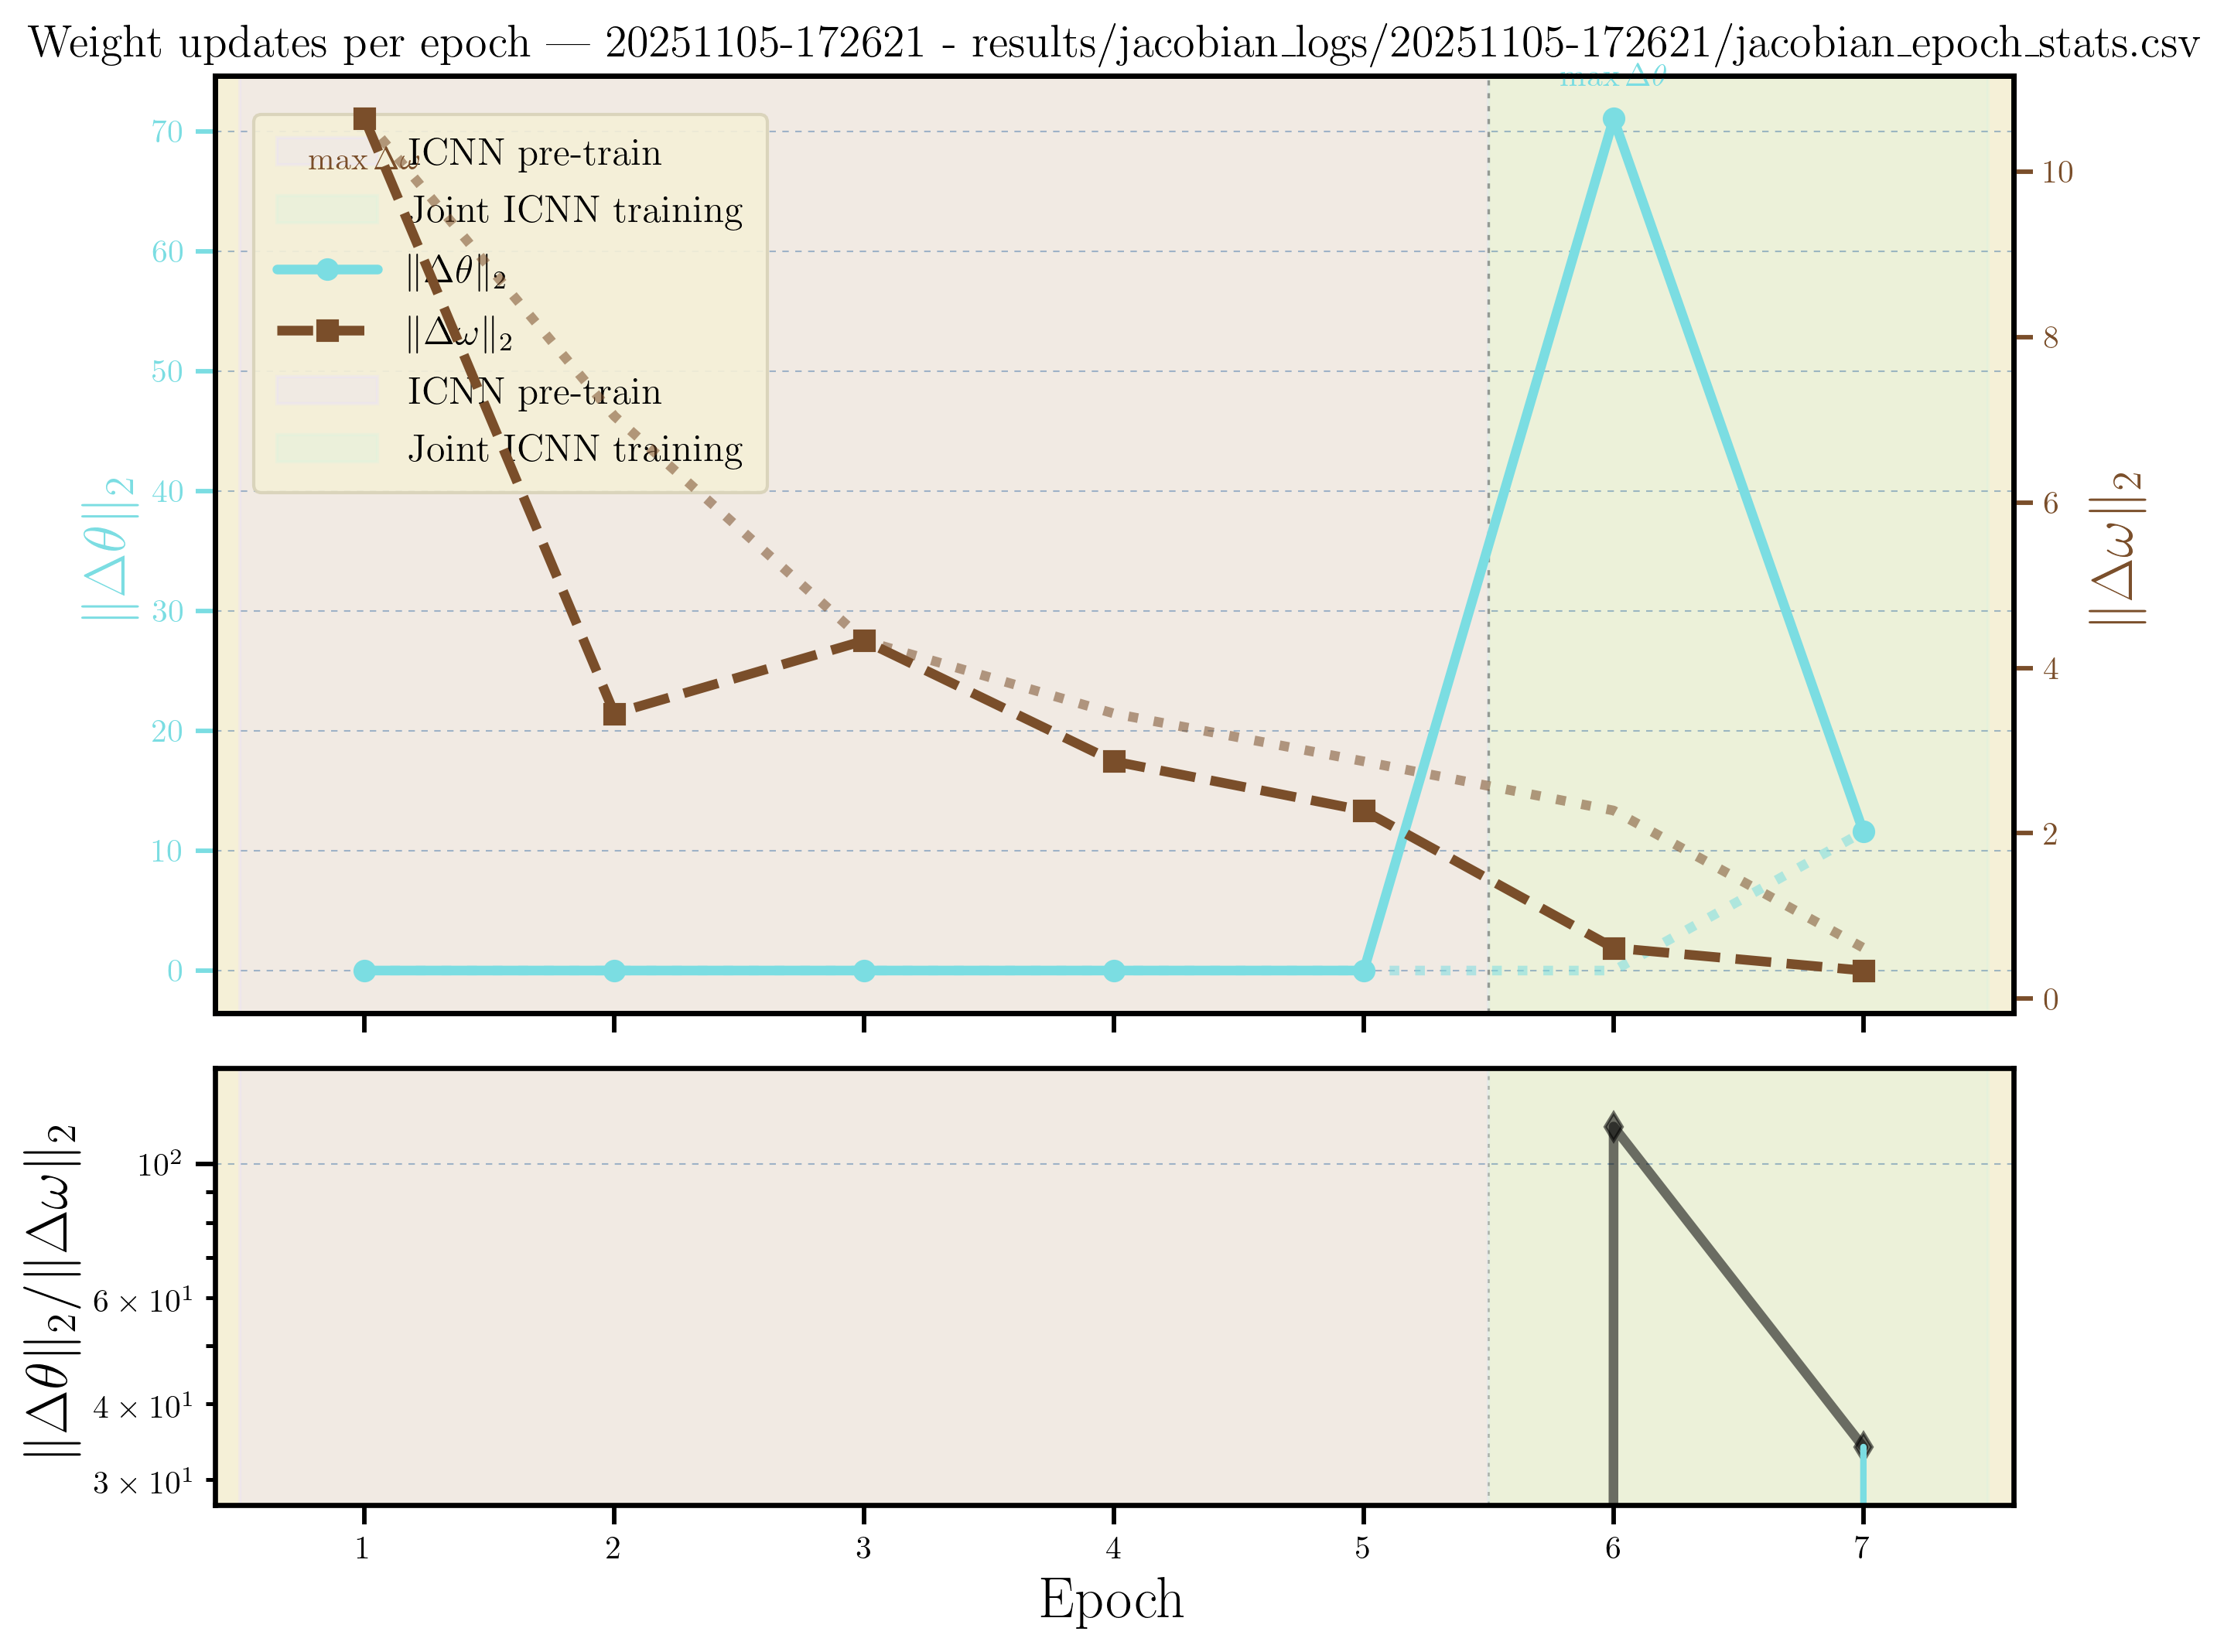

Saved weight delta figure to fig/weight_deltas/weight_deltas_20251105-172621---results-jacobian_logs-20251105-172621-jacobian_epoch_stats-csv.pdf


,metric,value
0,θ max Δ,71.0351
1,θ median Δ,0.0000
2,θ p10 Δ,0.0000
3,θ p90 Δ,35.3573
4,ICNN max Δ,10.6382
5,ICNN median Δ,2.8696
6,ICNN p10 Δ,0.5055
7,ICNN p90 Δ,6.8523
8,θ/ω median,0.0000
9,θ/ω min,0.0000


,epochs,theta_median,icnn_median,ratio_median
phase,,,,
icnn_pretrain,5,0.0000,3.4479,0.0000
icnn,2,41.3036,0.4781,74.6993


No evaluation JSON configuration provided; skipping robust accuracy plot.


In [4]:
# Manually specify the data sources you want to visualise.
# Edit the lists below with the CSV/JSON files you would like to plot.
WEIGHT_LOG_PATHS = [
    Path("results/jacobian_logs/20251105-172621/jacobian_epoch_stats.csv"),
    # Path("runs_log_icnn_pre-R2_seed-1_cut-avgpool_icnn-1024-512-512-256.csv"),
]

# Map each legend label to a list of evaluation JSON files. Leave empty to skip.
EVAL_JSON_CONFIG = {
    # "WRM-LAT (R2, gamma=0.25)": [
    #     Path("cifar10_variants_eval_ckpt-R2-adv-gamma-025_seed-1_inpP-inf_eps-0p0313725_steps-20_restarts-5_natural-0.json"),
    # ],
}

# Where to store generated figures (set to None to skip saving)
SAVE_WEIGHT_FIG_DIR = Path("fig/weight_deltas")
ROBUST_FIG_PATH = None  # e.g., Path("fig/manual_robust_accuracy.pdf")

# --- Weight delta plots -----------------------------------------------------
weight_paths = coerce_path_list(WEIGHT_LOG_PATHS)
if weight_paths:
    missing = [p for p in weight_paths if not p.exists()]
    if missing:
        missing_str = "\n".join(str(p) for p in missing)
        raise FileNotFoundError(
            f"Weight log file(s) not found:\n{missing_str}"
        )

    combined_logs, skipped_logs = load_weight_delta_frames(weight_paths)
    print(
        f"Loaded {combined_logs['run_id'].nunique()} run(s) across {len(weight_paths)} CSV file(s)."
    )
    if skipped_logs:
        skipped_str = ", ".join(str(p) for p in skipped_logs)
        print(f"Skipped {len(skipped_logs)} file(s) without required columns: {skipped_str}")

    save_dir = SAVE_WEIGHT_FIG_DIR if SAVE_WEIGHT_FIG_DIR else None
    for run_id, df_run in combined_logs.groupby("run_id", sort=False):
        df_run = df_run.sort_values("epoch").reset_index(drop=True)
        source_note = df_run["source"].iloc[0] if "source" in df_run else "manual"
        label = f"{run_id} - {source_note}"
        print(f"Plotting weight deltas for {label}")
        display_weight_delta_report(df_run, run_label=label, save_dir=save_dir)
else:
    print("No weight log paths configured; skipping weight delta plots.")

# --- Robust accuracy plots --------------------------------------------------
json_config_raw = {
    label: coerce_path_list(paths)
    for label, paths in EVAL_JSON_CONFIG.items()
    if paths
}
if json_config_raw:
    valid_json_config = {}
    missing_json = []
    for label, paths in json_config_raw.items():
        existing = [p for p in paths if p.exists()]
        missing_json.extend((label, p) for p in paths if not p.exists())
        if existing:
            valid_json_config[label] = existing
    if missing_json:
        missing_lines = "\n".join(f"{label}: {path}" for label, path in missing_json)
        print(f"Missing evaluation JSON file(s):\n{missing_lines}")
    if valid_json_config:
        save_path = ROBUST_FIG_PATH if ROBUST_FIG_PATH else None
        fig, source_map = plot_robust_accuracy(valid_json_config, save_path=save_path)
        if fig is not None:
            display(fig)
            if save_path:
                print(f"Saved robust accuracy plot to {save_path}")
            for label, sources in source_map.items():
                print(f"{label}: {', '.join(sources)}")
            plt.close(fig)
    else:
        print("No valid evaluation JSON files were provided; skipping robust accuracy plot.")
else:
    print("No evaluation JSON configuration provided; skipping robust accuracy plot.")

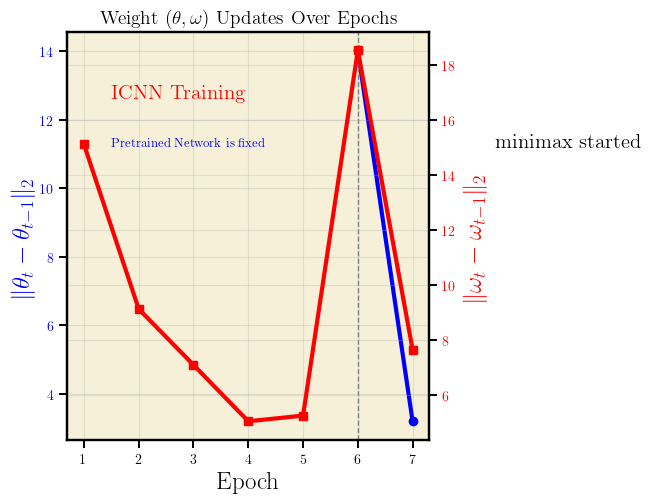

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# use famous seaborn style blue without border
# sns.set_theme(style="darkgrid", palette="pastel")
# sns.set_theme()
# sns.set_context("talk")



# results = pd.read_csv("/mnt/lts4/scratch/students/aabdolla/LAT/results/jacobian_logs/20251105-172621/jacobian_epoch_stats.csv")
# results = pd.read_csv("/mnt/lts4/scratch/students/aabdolla/LAT/results/jacobian_logs/20251105-182254/jacobian_epoch_stats.csv")
results = pd.read_csv("/mnt/lts4/scratch/students/aabdolla/LAT/results/jacobian_logs/20251115-210544/jacobian_epoch_stats.csv")
# print(results.head())
theta_weight_delta = results["theta_weight_delta"].iloc[-1]

# theta_weight_delta actually should starts at epoch 6 because the first 5 epochs are ICNN pretraining
theta_weight_delta = results["theta_weight_delta"].iloc[5:]
icnn_weight_delta = results["icnn_weight_delta"].iloc[-1]

# bacause icnn_weight_delta's values are much lower thatn theta_weight_delta, we should plot them on separate y-axes
fig, ax1 = plt.subplots(figsize=(7, 5.2), dpi=100)
ax2 = ax1.twinx()
ax1.plot(results["epoch"].iloc[5:], theta_weight_delta, label="$\\theta$ Weight Differences", color='b', marker='o')
ax2.plot(results["epoch"], results["icnn_weight_delta"], label="$\\text{ICNN}(\omega)$ Weight Differences", color='r', marker='s')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("$\\| \\theta_{t}-\\theta_{t-1}\|_{2}$", color='b')
ax2.set_ylabel("$\\| \\omega_{t}-\\omega_{t-1}\|_{2}$", color='r')
ax1.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')
plt.title("Weight $(\\theta, \\omega)$ Updates Over Epochs")
# for sixth epoch insert vertical line
ax1.axvline(x=6, color='gray', linestyle='--', linewidth=1)
# add text "ICNN Pretraining ends" above the line
ax1.text(1.5, max(theta_weight_delta)*0.9, "ICNN Training", color='r', fontsize=15)
ax1.text(1.5, max(theta_weight_delta)*0.8, "Pretrained Network is fixed", color='b', fontsize=9)
ax1.text(8.5, max(theta_weight_delta)*0.8, "minimax started", color='black', fontsize=15)
# adjust layout
fig.tight_layout()
# plt.legend(loc='upper right')
plt.grid(alpha=0.3)
# grid for ax1
ax1.grid(alpha=0.3)
ax2.grid(alpha=0.3)
# ax1.grid(axis="y", which="major", linestyle=(0, (4, 4)), linewidth=0.5,
#             color='#ADD8E6', alpha=0.45)
# # grid for ax2
# ax2.grid(axis="y", which="major", linestyle=(0, (4, 4)), linewidth=0.5,
#             color='#FFB6C1', alpha= 0.45)   

plt.show()


# # plot them separately where the x-axis is epoch and y-axis is weight delta
# plt.figure(figsize=(4, 3))
# plt.plot(results["epoch"].iloc[5:], theta_weight_delta, label="Theta Weight Delta", marker='o')
# plt.plot(results["epoch"], results["icnn_weight_delta"], label="ICNN Weight Delta", marker='s')
# plt.xlabel("Epoch")
# plt.ylabel("Weight Delta")
# plt.title("Weight Deltas over Epochs")
# plt.legend()
# plt.grid()
# plt.show()